In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("avocado-updated-2020.csv")

(From the main kaggle main page of dataset)
The dataset incudes Date - The date of the observation, AveragePrice - the average price of a single avocado, type - conventional or organic, year - the year, Region - the city or region of the observation, Total Volume - Total number of avocados sold, 4046 - Total number of avocados with PLU 4046 sold, 4225 - Total number of avocados with PLU 4225 sold, 4770 - Total number of avocados with PLU 4770 sold, and the number of bags for total, small, large, and xlarge. 

In [3]:
# Cleaning
df_clean = df.copy()
df_clean.isna().sum()
#no missing values

#renaming the columns to more descriptive titles
df_clean = df_clean.rename(columns={"4046": "small_medium_hass"})
df_clean = df_clean.rename(columns={"4225": "large_hass"})
df_clean = df_clean.rename(columns={"4770": "xlarge_hass"})


In [4]:
#using map to make larger categories for the geography column. 

geography_map = {
     "Total U.S.": "national",

    "Great Lakes": "major_region",
    "Midsouth": "major_region",
    "Northeast": "major_region",
    "Plains": "major_region",
    "South Central": "major_region",
    "Southeast": "major_region",
    "West": "major_region",
    "California": "major_region",
    
    "South Carolina": "other",
    "Northern New England": "other",
    "West Tex/New Mexico": "other"
}

df_clean["geography_type"] = (df_clean["geography"].map(geography_map).fillna("metro"))

#changing it to a category variable type
df_clean["geography_type"] = (
    df_clean["geography_type"].astype("category")
)

df_clean["geography_type"].value_counts()

#sorted(df["geography"].unique())

geography_type
metro           25704
major_region     4896
other            1833
national          612
Name: count, dtype: int64

Assumption:
I created a geography_type variable to separate the different geographic levels in the data. I classified Total U.S. as national and classified California, Great Lakes, Midsouth, Northeast, Plains, South Central, Southeast, and West as major_region. I included California because the dataset documentation lists it among the eight geographic areas connected to the Total U.S. figures. I interpreted this as suggesting that California should be treated as a major reporting region for this analysis, even though California is geographically part of the western United States. Because this interpretation is somewhat ambiguous, I kept California and West separate and did not add their totals together. South Carolina, Northern New England, and West Tex/New Mexico were classified as other, and all remaining locations were classified as metro.

In [5]:
#3: Which major geographical region sold the most total organic, small Hass avocados in 2017?

#filtering
Question3_df = df_clean[(df_clean["year"] == 2017) & (df_clean["geography_type"] == "major_region") & (df_clean["type"] == "organic")]

#using groupby for each major_region.
Question3_df.groupby("geography")["small_medium_hass"].sum().sort_values(ascending = False)

geography
West             1870206.29
South Central    1717104.19
California       1526290.58
Northeast         925832.36
Southeast         285124.34
Great Lakes       202487.68
Midsouth          186395.50
Plains            168583.40
Name: small_medium_hass, dtype: float64

#3 Answer: 
The West sold  the most total organic, small Hass avocados in 2017 at 1870206

In [6]:
#4. Split the date variable into month, day, and year variables. In which month is the highest average volume of avocado sales?

df_clean["date"] = pd.to_datetime(df_clean["date"])

df_clean["month"] = df_clean["date"].dt.month
df_clean ["day"] = df_clean["date"].dt.day


df_clean.groupby("month")["total_volume"].mean().sort_values(ascending = False)


month
5     1.123632e+06
2     1.095374e+06
6     1.051247e+06
4     1.016582e+06
3     9.957150e+05
1     9.853122e+05
7     9.832681e+05
8     9.499249e+05
9     9.064773e+05
10    8.446863e+05
11    8.223470e+05
12    8.076695e+05
Name: total_volume, dtype: float64

Assumption for #4: I only made another "month" and "day" column because "year" was already a column and I didn't want to be redundant.

#4 Answer: May had 1,123,632.25 avocado sales on average, making it the highest month. 

In [7]:
#5: Which metro area geographical regions sold the most total avocados? Plot side-by-side box-plots of the total volume for only the five metro geographical regions with the highest averages for the total_volume variable.

df_metro = df_clean[df_clean["geography_type"] == "metro"]
df_top5_names = df_metro.groupby("geography")["total_volume"].mean().sort_values(ascending= False).head(5).index
df_top5 = df_metro[df_metro["geography"].isin(df_top5_names)]

df_top5_names

Index(['Los Angeles', 'New York', 'Dallas/Ft. Worth', 'Houston',
       'Phoenix/Tucson'],
      dtype='object', name='geography')

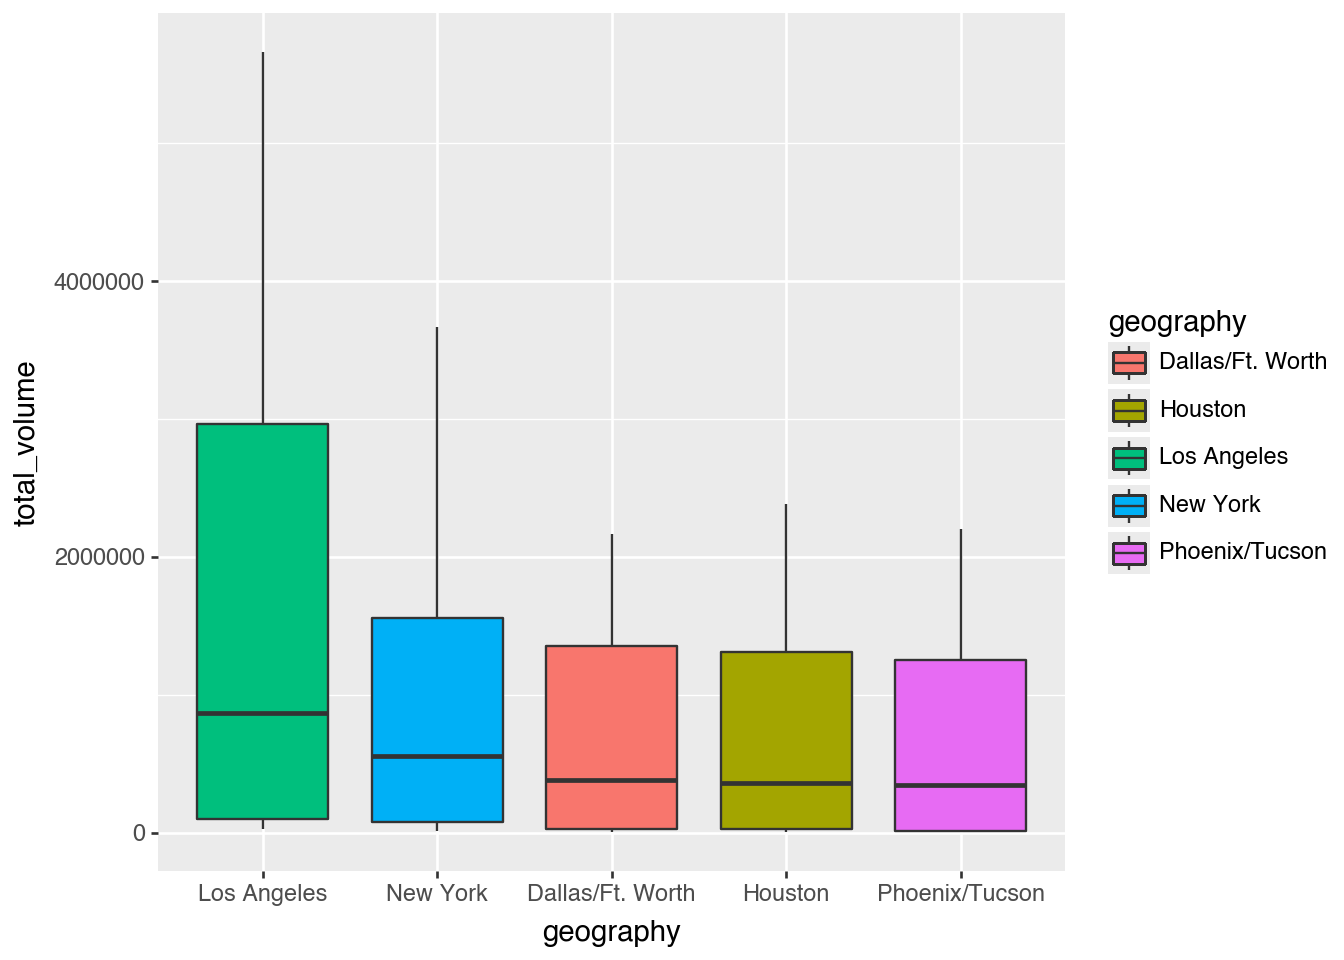

In [8]:
#boxplot

from plotnine import ggplot, aes, geom_boxplot, scale_x_discrete

(ggplot(df_top5,
aes(
  x = "geography",
  y = "total_volume",
  fill = "geography"
))
+ geom_boxplot()
+ scale_x_discrete(limits=list(df_top5_names))
)

Assumption: I treated each unique metro label in the original dataset as one metro reporting area. Therefore, combined labels such as Dallas/Ft. Worth and Phoenix/Tucson were kept as single regions rather than separated into individual cities. I ranked the metro regions using their average total_volume, selected the five highest, and retained all individual observations for those regions when creating the boxplots.

#5 Answer: The five metro regions with the highest average total volume were Los Angeles, New York, Dallas/Ft. Worth, Houston, and Phoenix/Tucson.

In [9]:
#6: From your cleaned data set, create a data set with only these California regions and answer the following questions about these California regions only.

cal_regions = ["Los Angeles", "San Diego", "Sacramento", "San Francisco"]

df_cal_regions = df_clean[df_clean["geography"].isin(cal_regions)]

df_cal_regions.shape



(2448, 16)

In [10]:
#7: In which California regions is the price of organic versus conventional avocados most different? Support your answer with a few summary statistics AND a visualization.
price_means = df_cal_regions.groupby(["geography", "type"], as_index = False)["average_price"].mean()

#pivoting to get the types in too different rows
price_pivot = price_means.pivot(index = "geography", columns = "type", values = "average_price")
price_pivot["differences_abs"] = (price_pivot["conventional"] - price_pivot["organic"]).abs()
price_pivot = price_pivot.sort_values("differences_abs", ascending = False)
price_pivot

#print(df_cal_regions.groupby(["geography", "type"])["average_price"].describe())


type,conventional,organic,differences_abs
geography,,,
San Francisco,1.400490,2.119444,0.718954
San Diego,1.113856,1.798366,0.684510
Sacramento,1.295359,1.873856,0.578497
Los Angeles,1.047124,1.574902,0.527778


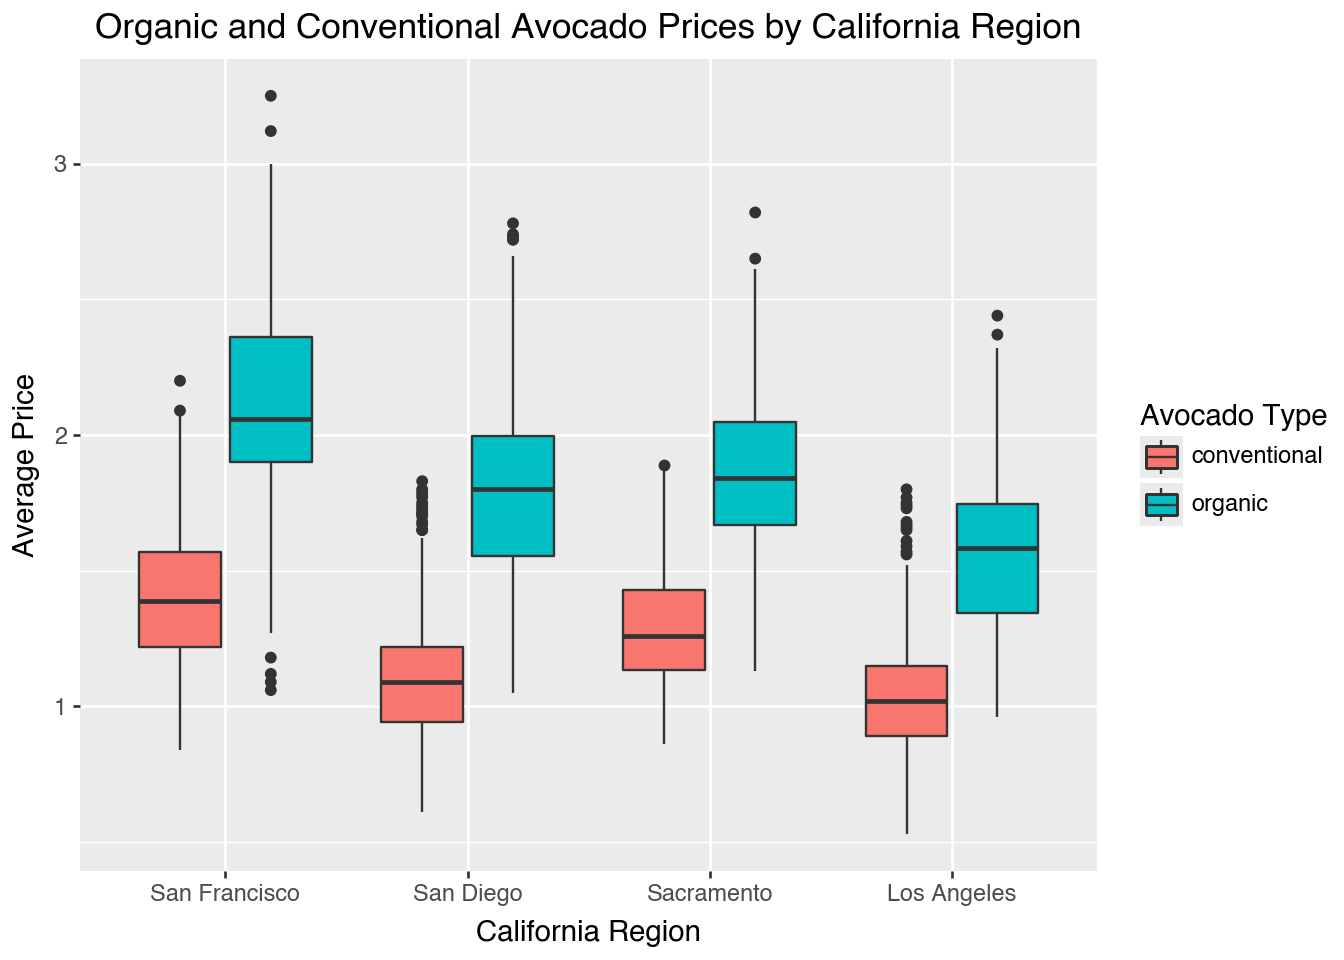

In [11]:
#boxplot visualization

from plotnine import ggplot, aes, geom_boxplot, scale_x_discrete, labs

(ggplot(df_cal_regions,
aes(
  x = "geography",
  y = "average_price",
  fill = "type"
))
+ geom_boxplot()
+ scale_x_discrete(limits=list(price_pivot.index))
+ labs(
    title="Organic and Conventional Avocado Prices by California Region",
    x="California Region",
    y="Average Price",
    fill="Avocado Type"
)
)

#7 Answer: I interpreted “most different” as the largest absolute difference between the mean organic and conventional avocado prices across all available dates. Based on this measure, San Francisco had the greatest price difference. Its mean conventional price was $1.40, compared with $2.12 for organic avocados, producing a difference of approximately $0.72. The differences were approximately $0.68 in San Diego, $0.58 in Sacramento, and $0.53 in Los Angeles. Organic avocados were more expensive on average in all four regions. The boxplots support this result by showing that organic prices were generally higher than conventional prices throughout each region.

In [12]:
#8 The following plot shows, for all four California regions, the proportion of the average Hass avocado sales that are small, large, or extra large; conventional vs. organic. Recreate the plot; you do not have to replicate the exact finishing touches - e.g., color, theme - but your plot should resemble the content of this plot.

#groping by geography, type, and sizes
region_size_type = df_cal_regions.groupby(["geography", "type"], as_index=False)[["small_medium_hass", "large_hass", "xlarge_hass"]].sum()


#creating a total column for each row
region_size_type["total_of_sizes"] = region_size_type["small_medium_hass"] + region_size_type["large_hass"] + region_size_type["xlarge_hass"]

#creating a new column for the proportion of each size 
region_size_type["small_medium_prop"] = region_size_type["small_medium_hass"] / region_size_type["total_of_sizes"]
region_size_type["large_prop"] = region_size_type["large_hass"] / region_size_type["total_of_sizes"]
region_size_type["xlarge_prop"] = region_size_type["xlarge_hass"] / region_size_type["total_of_sizes"]

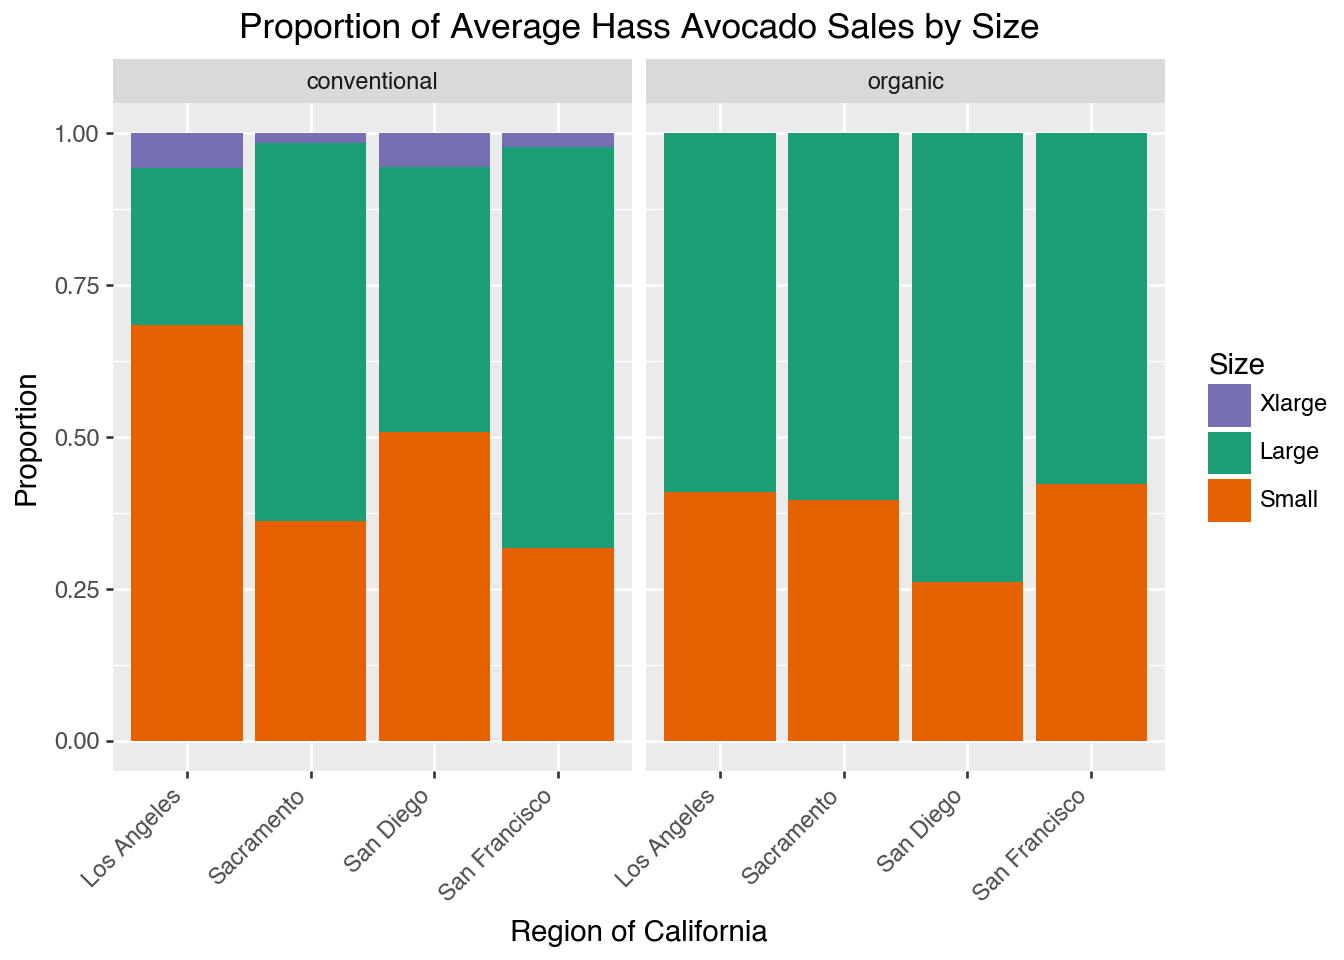

In [13]:
# 8 cont. 
#need to change from long to wide format

long_format = region_size_type.melt(
    id_vars=["geography", "type"],
    value_vars=[
        "small_medium_prop",
        "large_prop",
        "xlarge_prop"
    ],
    var_name="size",
    value_name="proportion"
)

#renaming and reordering
long_format["size"] = long_format["size"].replace({
    "small_medium_prop": "Small",
    "large_prop": "Large",
    "xlarge_prop": "Xlarge"
})

long_format["size"] = pd.Categorical(
    long_format["size"],
    categories=["Xlarge", "Large", "Small"],
    ordered=True
)

from plotnine import (ggplot, aes, geom_col, facet_wrap, labs, theme, element_text, scale_fill_manual)

(
    ggplot(
        long_format,
        aes(
            x="geography",
            y="proportion",
            fill="size"
        )
    )
    + geom_col()
    + facet_wrap("~type")
    + labs(
        title="Proportion of Average Hass Avocado Sales by Size",
        x="Region of California",
        y="Proportion",
        fill="Size"
    )
    + theme(
    axis_text_x=element_text(rotation=45, hjust=1)
    )
    + scale_fill_manual(
    values={
        "Small": "#E66101",
        "Large": "#1B9E77",
        "Xlarge": "#7570B3"
    }
)
)

In [14]:
#Using Outside Data

df_zillow_wide = pd.read_csv("zillow_house_data.csv")
df_zillow_wide.shape

#cleaning the data

#going from long to wide format
df_zillow_long = df_zillow_wide.melt(id_vars = ["RegionName"], value_vars= df_zillow_wide.columns[5:], var_name = "Date", value_name = "house_price")

#chaning date into pandas readable format and splitting the up
df_zillow_long["Date"] = pd.to_datetime(df_zillow_long["Date"])

df_zillow_long["year"] = df_zillow_long["Date"].dt.year
df_zillow_long["month"] = df_zillow_long["Date"].dt.month
df_zillow_long["day"] = df_zillow_long["Date"].dt.day



#mapping to create new geography column with correct string name and drop the other irrelevant cities
metro_map = {
    "Los Angeles, CA": "Los Angeles",
    "San Diego, CA": "San Diego",
    "Sacramento, CA": "Sacramento",
    "San Francisco, CA": "San Francisco"
}

df_zillow_long["geography"] = (df_zillow_long["RegionName"].map(metro_map))
df_zillow_cal = df_zillow_long.dropna().reset_index(drop=True)

df_zillow_cal["geography"] = (df_zillow_cal["geography"].astype("category"))

I downloaded monthly housing data from Zillow Research. The data reports Zillow’s estimate of the typical home value for metro regions over time. It originally came in wide format, with each month stored in a separate column, so I used melt() to change it into long format with one monthly observation per row.

I converted the date into a pandas date and created separate year, month, and day columns. I then matched the Zillow names for Los Angeles, San Diego, Sacramento, and San Francisco to the geography names used in the avocado data. All other regions and missing values were removed, the row index was reset, and geography was changed into a categorical variable.

In [15]:
#turning avocado's reporting to monthly from weekly with new dataframe
avocado_monthly = df_cal_regions.groupby(
    ["geography", "year", "month"],
    as_index=False
).agg(
    average_avocado_price=("average_price", "mean"),
    total_avocado_sales=("total_volume", "sum")
)

#joining datasets
avos_houses_inner = avocado_monthly.merge(df_zillow_cal[["geography", "year", "month", "house_price"]],
    on=["geography", "year", "month"],
    how="inner"
)

I changed the weekly avocado data into monthly data so it would match the monthly Zillow data. For each region and month, I calculated the mean avocado price and total avocado sales. I then joined the datasets using the matching region, year, and month. The inner join keeps only the months that appear in both datasets.

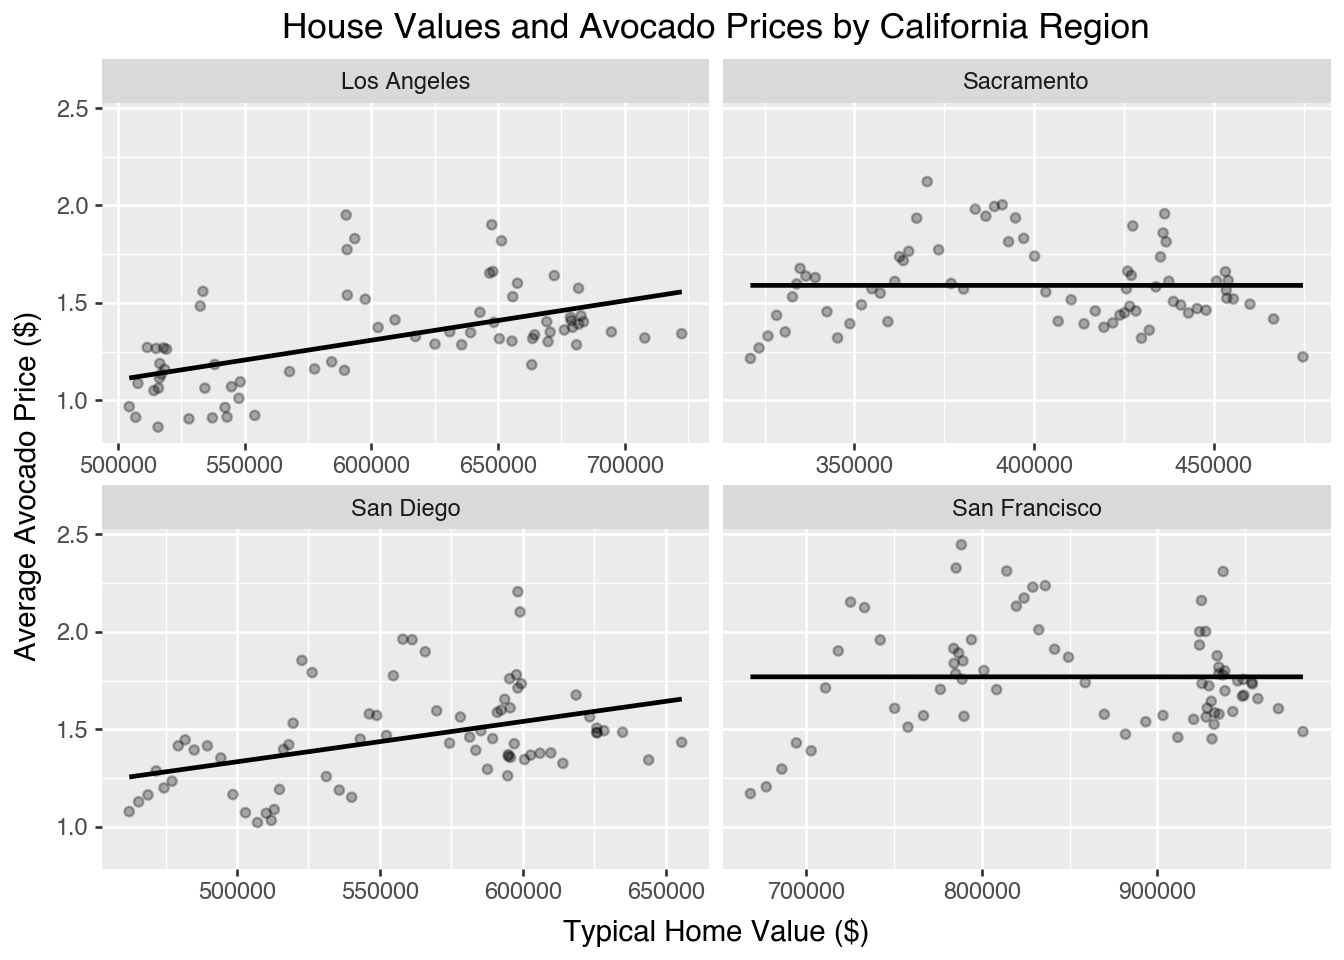

In [16]:
#Graph 1: House Values and Avocado Prices by California Region

from plotnine import (ggplot, aes, geom_point, geom_smooth, facet_wrap, labs)

(
    ggplot(
        avos_houses_inner,
        aes(
            x="house_price",
            y="average_avocado_price"
        )
    )
    + geom_point(alpha = .3)
    + geom_smooth(method="lm", se=False)
    + facet_wrap(
        "~geography",
        scales="free_x"
    )
    + labs(
        title="House Values and Avocado Prices by California Region",
        x="Typical Home Value ($)",
        y="Average Avocado Price ($)"
    )
)

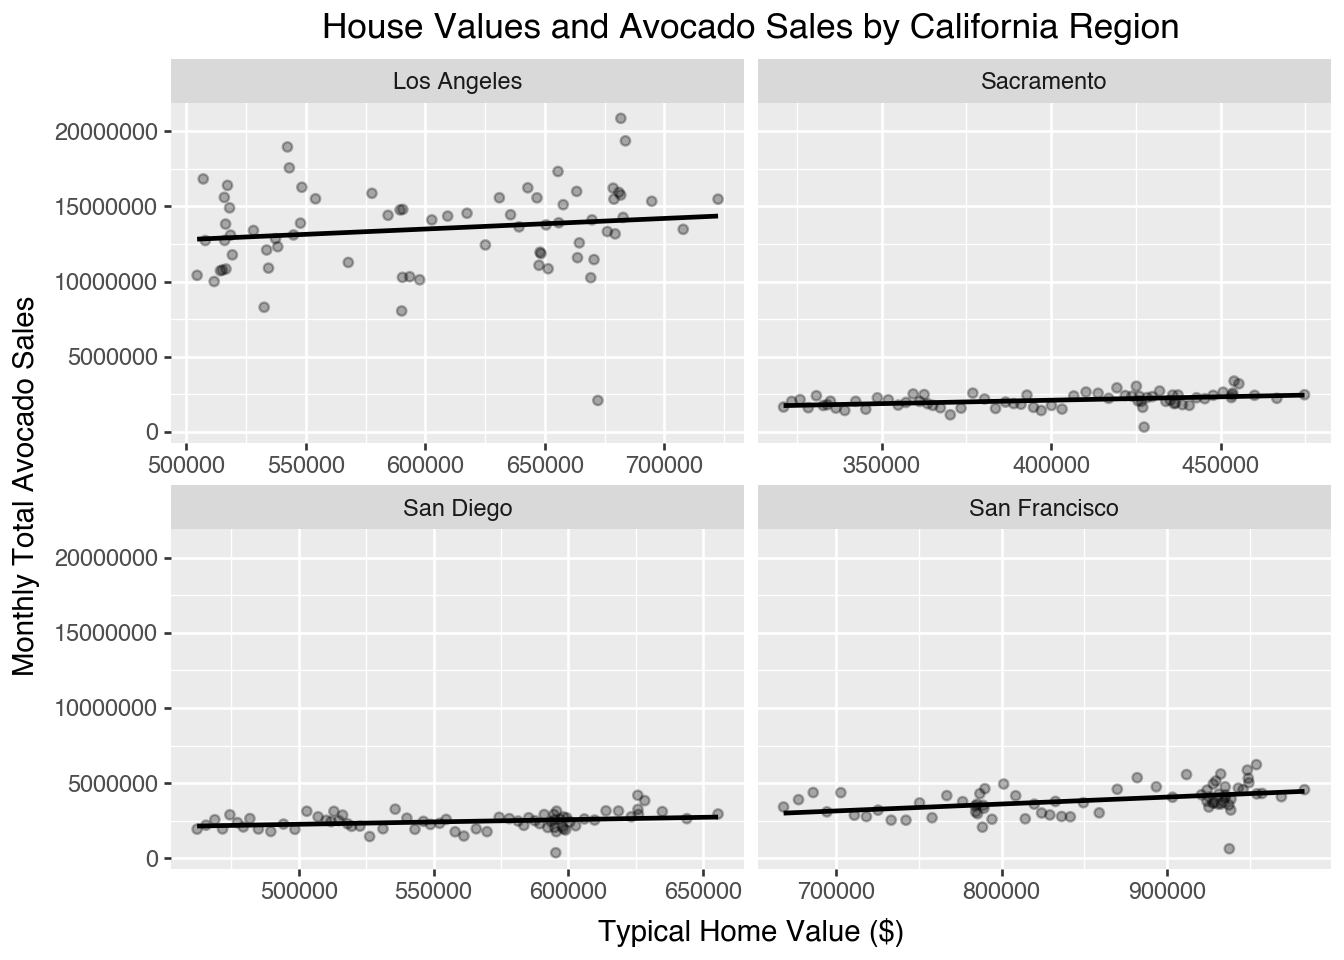

In [17]:
#Graph : House Values and Avocado Sales by California Region

from plotnine import (ggplot, aes, geom_point, geom_smooth, facet_wrap, labs)

(
    ggplot(
        avos_houses_inner,
        aes(
            x="house_price",
            y="total_avocado_sales"
        )
    )
    + geom_point(alpha = .3)
    + geom_smooth(method="lm", se=False)
    + facet_wrap(
        "~geography",
        scales="free_x"
    )
   + labs(
    title="House Values and Avocado Sales by California Region",
    x="Typical Home Value ($)",
    y="Monthly Total Avocado Sales"
)
)

Explanation/Argument: I decided to use scatterplots to look at how both avocado prices and total avocado sales relate to home values. The first graph shows that avocado prices generally increased with home values in Los Angeles and San Diego, while the trend lines for Sacramento and San Francisco were almost flat. The second graph shows a slight positive relationship between avocado sales and home values. If the avocado-toast joke were supported by these data, I might expect a clear negative relationship, where greater avocado sales were connected to lower housing values or affordability. Instead, avocado sales generally increased slightly as home values increased, so the results do not really support the joke. However, this data cannot directly prove or disprove the claim because home values are not the same as housing affordability, and the avocado sales represent entire regions rather than the spending habits of individual Millennials.